In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.load_data import (
    load_all_data,
    TARGET_LABELS
)

In [2]:
data = load_all_data(base_path='../data')

# Emotional Recognition Dataset
er_train = data['orig_train']
er_val = data['orig_val']
er_test = data['orig_test']

# GoEmotions Dataset
go_train = data['go_train']
go_val = data['go_val']
go_test = data['go_test']

# Combined datasets
full_train = data['full_train']
full_test = data['full_test']

In [3]:
print("EMOTION RECOGNITION DATASET")
print(f"Train Shape: {er_train.shape}")
print(f"Validation Shape: {er_val.shape}")
print(f"Test Shape: {er_test.shape}")
print("\nMissing Values in Train:\n", er_train.isnull().sum())

EMOTION RECOGNITION DATASET
Train Shape: (16000, 2)
Validation Shape: (2000, 2)
Test Shape: (2000, 2)

Missing Values in Train:
 text     0
label    0
dtype: int64


In [4]:
print("GO EMOTIONS DATASET")
print(f"Train Shape: {go_train.shape}")
print(f"Validation Shape: {go_val.shape}")
print(f"Test Shape: {go_test.shape}")
print("\nMissing Values in Train:\n", go_train.isnull().sum())

GO EMOTIONS DATASET
Train Shape: (33057, 2)
Validation Shape: (4134, 2)
Test Shape: (4067, 2)

Missing Values in Train:
 text     0
label    0
dtype: int64


In [5]:
print("COMBINED DATASET")
print(f"Full Train Shape: {full_train.shape}")
print(f"Full Test Shape: {full_test.shape}")
print("\nMissing Values in Combined Train:\n", full_train.isnull().sum())

COMBINED DATASET
Full Train Shape: (51629, 2)
Full Test Shape: (6067, 2)

Missing Values in Combined Train:
 text     0
label    0
dtype: int64


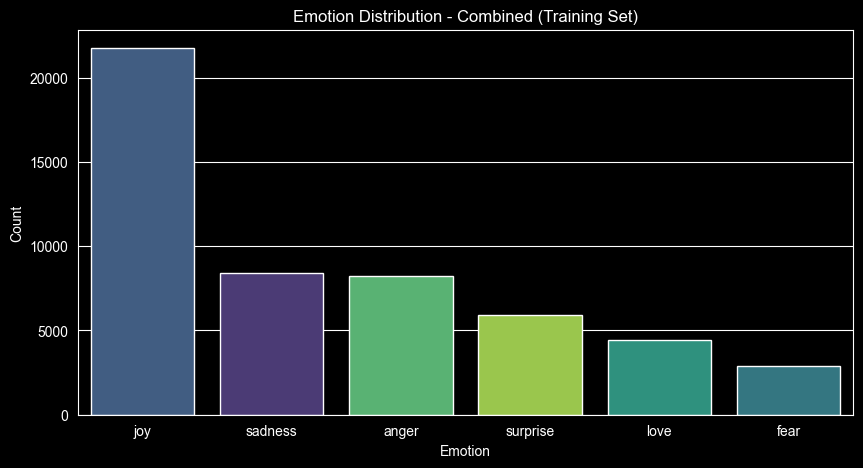

In [6]:
# Emotion distribution - Combined Dataset
plt.figure(figsize=(10, 5))
sns.countplot(data=full_train, x='label', order=full_train['label'].value_counts().index, palette='viridis', hue='label')
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Emotion Distribution - Combined (Training Set)")
plt.show()

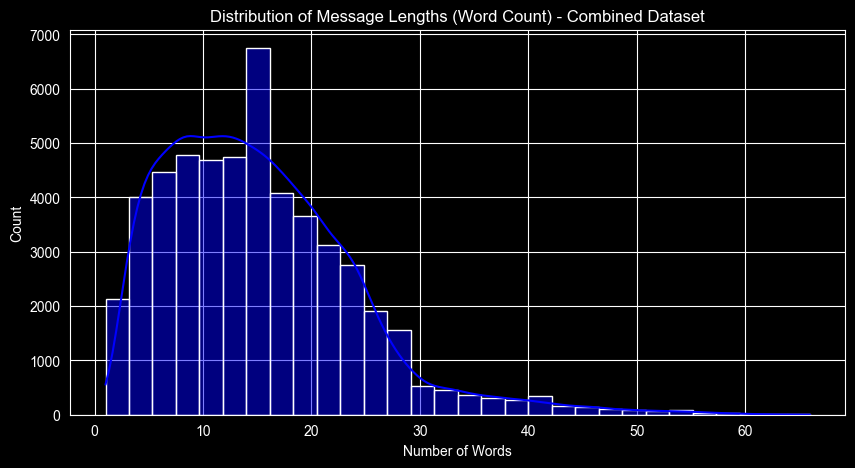

In [7]:
# Message length distribution - Combined Dataset
full_train['text_len'] = full_train['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(full_train['text_len'], bins=30, kde=True, color='blue')
plt.title("Distribution of Message Lengths (Word Count) - Combined Dataset")
plt.xlabel("Number of Words")
plt.show()

In [8]:
# Avg word count and max word count
full_train['word_count'] = full_train['text'].apply(lambda x: len(x.split()))
print(f"Average words per message: {full_train['word_count'].mean():.2f}")
print(f"Max words: {full_train['word_count'].max()}")

Average words per message: 15.17
Max words: 66


In [9]:
print("Samples of each emotion:")
for label in TARGET_LABELS:
    sample = full_train[full_train['label'] == label]['text'].iloc[0]
    print(f"[{label.upper()}]: {sample[:80]}...")

Samples of each emotion:
[SADNESS]: i wasnt so terribly sore i would feel a bit regretful but theres papers to write...
[JOY]: Whenever I'm having a bad day, I watch a few eps of Cosmos to chill out....
[LOVE]: i is thirteen again and so so unsure of himself and unsure of how he feels about...
[ANGER]: i dunno, you commit one little genocide and you never hear the fucking end of it...
[FEAR]: i am feeling unsure of how to handle a new phase one of my kids is in or feeling...
[SURPRISE]: I can answer this! It's alright. Interesting little snippets that make me curiou...


In [10]:
print(f"Number of Duplicated Messages: {full_train.duplicated().sum()}")

Number of Duplicated Messages: 0
